# Глава 6. Модель Хольта-Винтерса (тройное экспоненциальное сглаживание, ETS)

## 1. Теория

### 1.1 Экспоненциальное сглаживание

**Экспоненциальное сглаживание** — прогноз как взвешенное среднее прошлых значений, где вес **экспоненциально убывает** с давностью: вчера весит больше, чем позавчера, позавчера — больше, чем неделю назад, и так далее. Насколько быстро модель «забывает» прошлое, задаёт коэффициент сглаживания $\large \alpha$ от 0 до 1.

#### Из каких частей модель собирает прогноз
- Представляем каждое значение ряда как сумму (или произведение) нескольких понятных компонент. Пример — заказы юнита за неделю: пн=200, вт=210, ср=220, чт=230, пт=300, сб=340, вс=250. Тогда компоненты будут:
	- **Уровень** $\large \ell$ — «сколько обычно» у ряда **сейчас**, если убрать день недели и случайный шум. Здесь это 250 заказов в день (среднее за неделю: 1750 / 7). Значит, «юнит сейчас живёт на 250 заказов в день». Это одно число на каждый момент времени, и оно медленно сдвигается по мере прихода новых данных.
	- **Тренд** $\large b$ — **наклон** уровня: на сколько уровень меняется за один шаг. Если через месяц типичный день стал 280 вместо 250, уровень рос примерно на +1 в день — это и есть тренд. Тренд нет смысла считать без уровня: он отвечает не на вопрос «где ряд», а на вопрос «куда и как быстро он движется».
	- **Сезонность** $\large I$ — повторяющаяся **поправка** к уровню для конкретной точки цикла, то есть отклонение факта от уровня. Насколько конкретный день недели отличается от типичного? Считаем как: факт − уровень ("типичный день"). Например:
		- понедельник: 200 − 250 = −50, на 50 меньше обычного
		- пятница: 300 − 250 = +50, на 50 больше обычного
	- **Шум** — всё, что осталось: дождь в среду дал +15, сбой доставки в четверг −20. Модель его не объясняет и не прогнозирует.
- **Прогноз** = **Уровень** + (**Тренд** × **Шаги вперёд**) + **Сезонность**. Например, прогноз на пятницу через $\large m$ дней: $\large 250 + (1 \cdot m) + 50$.

### 1.2 Семейство моделей строится по мере добавления компонент:

- **Простое экспоненциальное сглаживание** `SimpleExpSmoothingModel` — используется, когда нет тренда и сезонности, только «шум» вокруг среднего уровня. Прогноз на любой шаг вперёд — последний уровень, горизонтальная линия: $$\LARGE F_{t+m} = \ell_t$$
  Уровень обновляется на каждом шаге обучения: $$\LARGE \ell_t = \alpha Y_t + (1 - \alpha)\ell_{t-1}$$

- **Двойное экспоненциальное сглаживание (метод Хольта)** `HoltModel` — используется, когда ряд **имеет тренд**: простое сглаживание будет постоянно отставать от растущего ряда. Поэтому Хольт добавил второй слой сглаживания — для тренда. Прогноз — наклонная прямая от последнего уровня: $$\LARGE F_{t+m} = \ell_t + m\,b_t$$
  Уровень и тренд обновляются на каждом шаге обучения: $$\LARGE
    \begin{cases}
       \ell_t = \alpha Y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1}) \\
       b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1}
    \end{cases}
$$

- **Тройное экспоненциальное сглаживание (модель Хольта-Винтерса)** `HoltWintersModel` — используется, когда ряд **имеет и тренд, и сезонность**. Добавляется третий компонент — сезонный индекс. Прогноз — наклонная прямая с наложенным сезонным узором. Вариант с аддитивным трендом и аддитивной сезонностью: $$\LARGE F_{t+m} = \ell_t + m\,b_t + I_{t-L+1+(m-1)}$$
  То есть: последний уровень + наклон × число шагов вперёд + сезонная поправка для этой точки цикла из последнего полного цикла. Индекс $\large t-L+1+(m-1)$ — это то же самое, что $\large t+m-L$.
  Уровень, тренд и сезонный индекс обновляются на каждом шаге обучения: $$\LARGE
    \begin{cases}
       \ell_t = \alpha (Y_t - I_{t-L}) + (1 - \alpha)(\ell_{t-1} + b_{t-1}) \\
       b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1} \\
       I_t = \gamma (Y_t - \ell_{t-1} - b_{t-1}) + (1 - \gamma)I_{t-L}
    \end{cases}
$$

где (обозначения общие для всех трёх моделей):
- $\large Y_{t}$ — фактическое значение ряда в момент времени $\large t$.
- $\large \ell_{t}$ — **уровень** в момент $\large t$: «где сейчас ряд», очищенный от сезонности и шума. В простом сглаживании уровень и есть прогноз.
- $\large b_{t}$ — **тренд** в момент $\large t$: на сколько уровень меняется за один шаг (наклон). Считается как сглаженная разница соседних уровней $\large \ell_t - \ell_{t-1}$.
- $\large I_{t}$ — **сезонный индекс** в момент $\large t$: поправка для этой точки цикла (например, «пятница — на 50 заказов выше уровня»).
- $\large L$ — длина сезонного цикла, `seasonal_periods` (7 для недельной сезонности на дневных данных); $\large I_{t-L}$ — индекс той же точки цикла в прошлом цикле.
- $\large m$ — на сколько шагов вперёд строится прогноз.
- $\large F_{t+m}$ — прогноз на момент $\large t+m$.
- $\large \alpha, \beta, \gamma \in [0, 1]$ — коэффициенты сглаживания уровня, тренда и сезонности (`smoothing_level` / `smoothing_trend` / `smoothing_seasonal`). Смысл у всех одинаковый:
    - близко к 1 — сглаживание **слабое**: компонента быстро подстраивается под свежие данные и быстро «забывает» прошлое;
    - близко к 0 — сглаживание **сильное**: компонента меняется медленно и дольше «помнит» прошлое;
    - для $\large \beta$: около 0 — наклон почти постоянный, около 1 — наклон пересчитывается по последним точкам;
    - для $\large \gamma$: около 0 — недельный узор почти не меняется со временем, около 1 — узор каждую неделю переписывается по последней неделе.


#### Отличие от
- `SeasonalMovingAverageModel` тоже прогнозирует «тем же днём прошлых недель», но берёт `window` последних сезонов с **равными** весами и не знает про тренд. Хольт-Винтерс отдельно ведёт уровень, тренд и сезонный узор, и веса у прошлых наблюдений **экспоненциально убывают**.
- `SARIMAXModel` сначала делает ряд стационарным (`d`/`D`) и моделирует корреляции между точками. Хольт-Винтерс раскладывает ряд на понятные компоненты — уровень, тренд, сезонность — и **не требует стационарности**: тренд и сезонность здесь не убираются, а прямо моделируются. Поэтому никаких `adfuller` и ACF/PACF перед запуском не нужно.

### 1.3 Таксономия: какие бывают тренд и сезонность.

Конкретная формула модели определяется двумя вопросами: **как меняется уровень** (тип тренда) и **как сезонная волна связана с уровнем** (тип сезонности). Все формулы из пособия — это таблица «тип тренда × тип сезонности», и каждая клетка — своя модель. Аддитивный вариант строится через «плюс», мультипликативный — через «умножить».

**Тренд — как меняется уровень со временем:**
- **Без тренда** — ряд колеблется вокруг постоянного уровня. Прогноз — горизонтальная линия (плюс сезонность).
- **Аддитивный** — уровень меняется на **одинаковое число единиц** за шаг: «+5 заказов в день». На графике — прямая линия. В формулах: $\large \ell_t + m\,b_t$.
- **Аддитивный с затуханием** — то же, но рост постепенно **замедляется и выходит на плато**: каждый следующий шаг добавляет долю $\large \phi$ (от 0 до 1) от предыдущего прироста. Реалистичнее на длинном горизонте: обычный тренд — бесконечная прямая, которая рано или поздно уйдёт в небо или в ноль.
- **Мультипликативный** — уровень меняется на **одинаковый процент** за шаг: «+2% в день». На графике — кривая, которая ускоряется (экспонента). В формулах: $\large \ell_t \cdot b_t^m$, где $\large b_t$ — коэффициент роста около 1.
- **Мультипликативный с затуханием** — процентный рост, который постепенно гаснет.

**Сезонность — как сезонная волна связана с уровнем:**
- **Без сезонности** — повторяющегося узора нет.
- **Аддитивная** — сезонная поправка в **штуках**: «в пятницу на 50 заказов больше уровня». **Размах волны постоянный** и не зависит от уровня: при уровне 200 и при уровне 400 пятница всё так же «+50». Индекс $\large I$ — число около 0, за цикл поправки в сумме дают ≈ 0. В формулах: $\large \ldots + I$.
- **Мультипликативная** — сезонная поправка в **разах**: «в пятницу в 1.3 раза больше уровня». **Размах волны растёт вместе с уровнем**: при уровне 200 пятница «+60», при уровне 400 уже «+120». Индекс $\large I$ — коэффициент около 1, в среднем за цикл ≈ 1. В формулах: $\large (\ldots) \cdot I$. Работает только на строго положительных данных.



### 1.4 Параметры и реализация

Исходник `etna/models/holt_winters.py`, класс `HoltWintersModel` (сигнатура сокращена):

```python
class HoltWintersModel(PerSegmentModelMixin, ...):
    def __init__(
        self,
        trend: Optional[str] = None,
        damped_trend: bool = False,
        seasonal: Optional[str] = None,
        seasonal_periods: Optional[int] = None,
        initialization_method: str = "estimated",
        use_boxcox: Union[bool, str, float] = False,
        smoothing_level: Optional[float] = None,
        smoothing_trend: Optional[float] = None,
        smoothing_seasonal: Optional[float] = None,
        damping_trend: Optional[float] = None,
        ...
    ):
```

**Параметры `HoltWintersModel`:**
- `trend` *(по умолчанию `None`)* — тип тренда: `None`, `"add"`/`"additive"`, `"mul"`/`"multiplicative"`.
- `damped_trend` *(по умолчанию `False`)* — затухающий тренд: наклон постепенно гасится с горизонтом (сила затухания — `damping_trend`, $\phi$).
- `seasonal` *(по умолчанию `None`)* — тип сезонности: `None`, `"add"`, `"mul"`.
- `seasonal_periods` — длина сезонного цикла $L$: `7` для недельной сезонности на дневных данных, `12` — для годовой на месячных. Обязателен, если задан `seasonal`.
- `smoothing_level` / `smoothing_trend` / `smoothing_seasonal` — коэффициенты $\alpha$ / $\beta$ / $\gamma$. **По умолчанию `None` — оцениваются в `fit()` оптимизацией** (минимизация ошибки на train); если задать числом — фиксируются руками.
- `initialization_method` *(по умолчанию `"estimated"`)* — как получить стартовые $\ell_0$, $b_0$, $I_{1..L}$: оценить вместе с коэффициентами или эвристикой по первым циклам.
- `use_boxcox` — преобразование Бокса-Кокса перед сглаживанием (`True`, `"log"` или число $\lambda$), стабилизирует разброс.

**Младшие модели семейства** — тот же движок, урезанный набор параметров:
- `SimpleExpSmoothingModel(smoothing_level=...)` — только уровень;
- `HoltModel(exponential=False, damped_trend=False, smoothing_level=..., smoothing_trend=..., ...)` — уровень + тренд.

**Под капотом и в сравнении с `SARIMAXModel`:**
- внутри — `statsmodels.tsa.holtwinters.ExponentialSmoothing`, отдельная модель на каждый сегмент (`PerSegmentModelMixin`), как у SARIMAX;
- API тот же: `model.fit(train_ts)` → `train_ts.make_future(HORIZON)` → `model.forecast(future_ts)`, без `tail_steps`/`prediction_size`;
- экзогенные регрессоры **не поддерживаются** — только сам ряд;
- `model.get_model()` → `{segment: HoltWintersResultsWrapper}`: подобранные коэффициенты в `.params` (`smoothing_level`, `smoothing_trend`, `smoothing_seasonal`, ...), сами компоненты в `.level`, `.trend`, `.season`, сглаженные значения — `.fittedvalues`;
- `model.forecast(future_ts, return_components=True)` — помимо прогноза отдаёт его разложение на компоненты `target_component_level` / `..._trend` / `..._seasonality`.

## 2. Данные

Те же файлы, что и в предыдущих тетрадях (`local/data/`, в `.gitignore`):
- `units.csv` — 10 юнитов; для основной практики берём 2 из них (размер `10+`, typical + busier), для бонуса — все 10.
- `facts-by-date.csv` — дневные факты, 2022-01-01…2026-08-31.

Период и сплит — как в прошлых тетрадях: с 2026-04-01, test — последние 14 дней (2026-08-18 … 2026-08-31). Тогда результаты сравнимы с `NaiveModel` / `MovingAverageModel` / `SeasonalMovingAverageModel` / `SARIMAXModel` напрямую, в том числе в MLflow.

В этой главе не сравниваем с продовым прогнозом (`forecasts-by-date.csv`) — это отдельная тема, которой займёшься сам.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from etna.datasets import TSDataset
from etna.models import HoltWintersModel, HoltModel, SimpleExpSmoothingModel, SARIMAXModel
from etna.metrics import SMAPE, WAPE, MAPE, MAE
from etna.analysis import plot_forecast

from src.custom_logger import log_to_mlflow
from src.prod_metrics import bias, pooled

DATA_DIR = "../../local/data"
HORIZON = 14

/Users/skv/projects-skv/study-etna/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Практика

От простого к сложному: сначала на синтетике проходим всё семейство — уровень → тренд → сезонность — и разбираем прогноз руками по формуле, потом сравниваем аддитивную и мультипликативную сезонность, и только после этого переходим к реальным юнитам и сравнению с SARIMAX.

### Задание 1. Синтетика: уровень → тренд → сезонность

1. Собери синтетический ряд с **трендом и недельной сезонностью** и немного шума — так же, как в тетради про SARIMAX (линейный тренд + недельный паттерн + `np.random.normal`), только подлиннее, например 10–12 недель. Оберни его в `TSDataset` с одним сегментом (`segment="synthetic"`).
2. Раздели на train/test, test — последние 14 дней.
3. Обучи по очереди три модели с коэффициентами по умолчанию (подбираются сами): `SimpleExpSmoothingModel()`, `HoltModel()`, `HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7)`.
4. Нарисуй все три прогноза на одном графике (`plot_forecast` принимает словарь `{имя: forecast_ts}`) и посчитай SMAPE каждого.
5. Объясни форму каждого прогноза по разделу 1.2: почему у первой модели горизонтальная линия, у второй — наклонная, у третьей — наклонная «пила»? Какая компонента ряда каждый раз «не помещается» в модель?

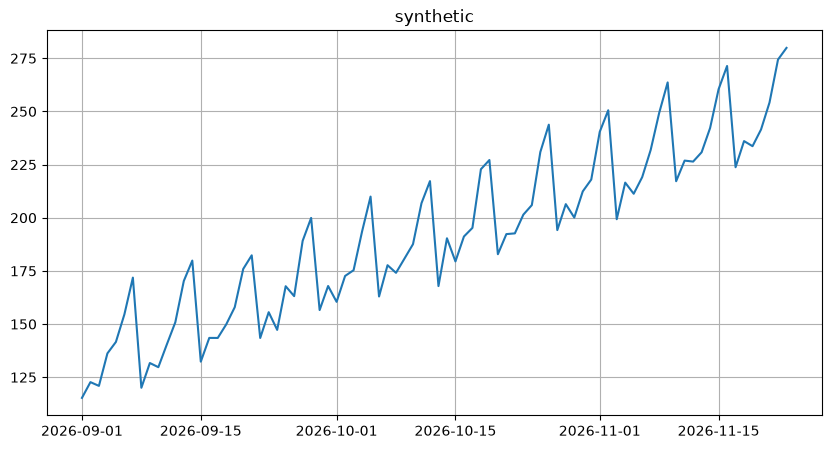

In [2]:
# Синтетика: тренд + недельная сезонность + немного шума
np.random.seed(0)
periods = 84  # 12 недель

day_of_week_pattern = np.array([10, 20, 15, 25, 30, 50, 60], dtype=float)
seasonal = np.tile(day_of_week_pattern, periods // 7 + 1)[:periods]
trend = np.arange(periods) * 1.5
noise = np.random.normal(0, 3, periods)

df = pd.DataFrame({
    "timestamp": pd.date_range("2026-09-01", periods=periods, freq="D"),
    "segment": "synthetic",
    "target": seasonal + trend + 100 + noise,
})

ts = TSDataset(df=df, freq="D")
ts.plot();

In [3]:
train_ts, test_ts = ts.train_test_split(test_size=14)

errors = {}

In [4]:
# Простое экспоненциальное сглаживание
model_simple = SimpleExpSmoothingModel()
model_simple.fit(train_ts)
future_simple = train_ts.make_future(future_steps=HORIZON)
forecast_simplt = model_simple.forecast(future_simple)
errors["simple"] = SMAPE()(y_true=test_ts, y_pred=forecast_simplt)

In [5]:
# Двойное экспоненциальное сглаживание
model_double = HoltModel()
model_double.fit(train_ts)
future_double = train_ts.make_future(future_steps=HORIZON)
forecast_double = model_double.forecast(future_double)
errors["double"] = SMAPE()(y_true=test_ts, y_pred=forecast_double)

In [6]:
# Тройное экспоненциальное сглаживание
# HoltWintersModel() без параметров по умолчанию собирается с trend=None, seasonal=None и это будет обычный SimpleExpSmoothingModel()
model_triple = HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7)
model_triple.fit(train_ts)
future_triple = train_ts.make_future(future_steps=HORIZON)
forecast_triple = model_triple.forecast(future_triple)
errors["triple"] = SMAPE()(y_true=test_ts, y_pred=forecast_triple)

{'simple': {'synthetic': 6.6510059030156095},
 'double': {'synthetic': 5.820375715534911},
 'triple': {'synthetic': 1.0147928392773}}

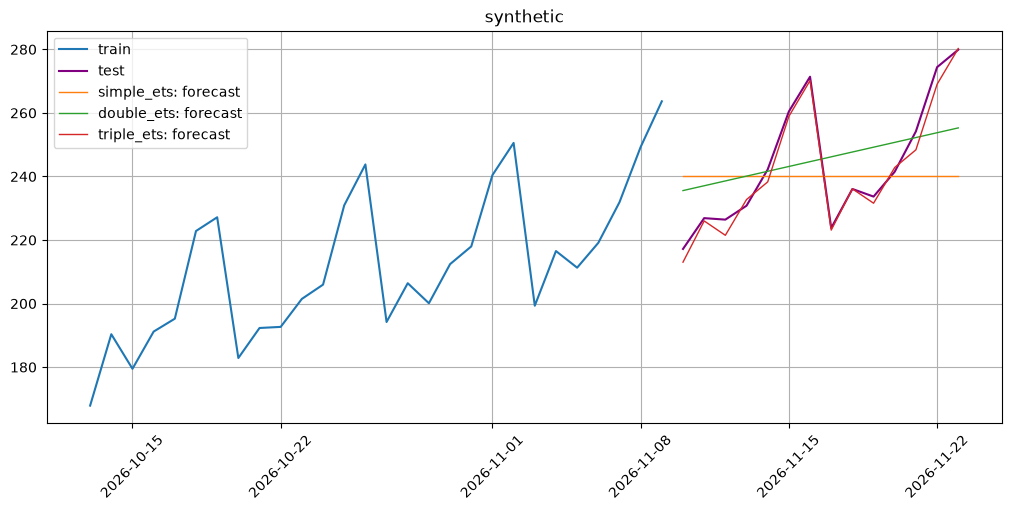

In [7]:
plot_forecast(
    forecast_ts={
        "simple_ets" : forecast_simplt,
        "double_ets": forecast_double,
        "triple_ets": forecast_triple,
    },
    test_ts=test_ts,
    train_ts=train_ts,
    n_train_samples=4 * 7,
)
errors

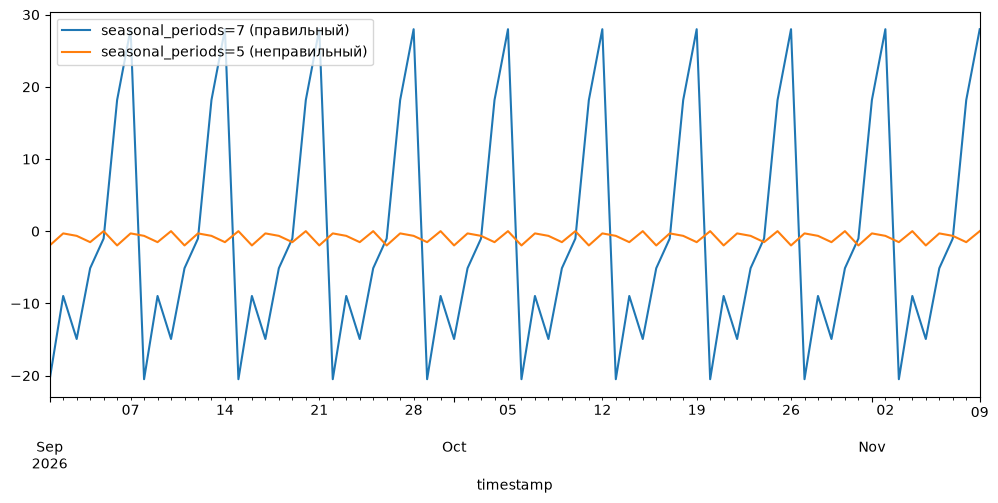

In [8]:
# Тройное экспоненциальное сглаживание с НЕПРАВИЛЬНЫМ периодом: seasonal_periods=5 вместо 7
model_triple_error = HoltWintersModel(trend="add", seasonal="add", seasonal_periods=5)
model_triple_error.fit(train_ts)
future_triple_error = train_ts.make_future(future_steps=HORIZON)
forecast_triple_error = model_triple_error.forecast(future_triple_error)
errors["triple_error"] = SMAPE()(y_true=test_ts, y_pred=forecast_triple_error)

# Почему прогноз получается почти как у Хольта (двойного сглаживания)?

# Модель заводит 5 сезонных поправок — по одной на каждую позицию «цикла из 5 дней» — и считает, что позиция 1 каждый раз означает одно и то же.
# Но настоящий цикл — 7 дней, поэтому позиция 1 каждый цикл приходится на РАЗНЫЙ день недели: 1-й цикл → пн, 2-й → сб, 3-й → чт, 4-й → вт, ...
# Поправку для позиции 1 «тянут» то понедельник (−20), то суббота (+30), то четверг (−5) — в среднем они гасят друг друга, и поправка уходит к нулю.
# То же со всеми пятью позициями.
# Итог: сезонные поправки ≈ 0, и прогноз ℓ + m·b + I превращается в ℓ + m·b — это и есть Хольт.

# Проверка — смотрим на РАЗМЕР сезонных поправок:
#   период 7 — чёткая «пила» (≈ −20 … +28, наш недельный паттерн минус его среднее);
#   период 5 — мелкие значения около нуля, узор не найден.
ax = model_triple.get_model()["synthetic"].season.plot(
    label="seasonal_periods=7 (правильный)",
    figsize=(12, 5),
)
model_triple_error.get_model()["synthetic"].season.plot(ax=ax, label="seasonal_periods=5 (неправильный)")
ax.legend(loc="upper left");

### Задание 2. Разбираем прогноз руками

Цель — убедиться, что прогноз Хольта-Винтерса — это не чёрный ящик, а ровно формула из раздела 1.2.

1. На train из Задания 1 обучи `statsmodels`-модель напрямую — `ExponentialSmoothing(series, trend="add", seasonal="add", seasonal_periods=7, initialization_method="estimated").fit(smoothing_level=..., smoothing_trend=..., smoothing_seasonal=...)` — с **фиксированными** коэффициентами (например, `0.3 / 0.05 / 0.2`).
2. Собери датафрейм из факта `y`, уровня `.level`, тренда `.trend`, сезонности `.season` и сглаженных значений `.fittedvalues`. Посмотри на последние строки — как ведут себя уровень, тренд и сезонность от шага к шагу?
3. Посчитай руками прогноз на 1 и 2 шага вперёд по формуле $F_{t+m} = \ell_t + m\,b_t + I_{t-L+1+(m-1)}$ и сравни с `.forecast(HORIZON)` — должны совпасть.
4. Обучи `HoltWintersModel` из ETNA с теми же фиксированными коэффициентами и сравни его прогноз с прогнозом `statsmodels` — совпадают? (раздел 1.4: что лежит под капотом).
5. Получи прогноз ETNA с `return_components=True` и посмотри на компоненты `level` / `trend` / `seasonality`: их сумма должна давать `target`.

In [9]:
# Шаг 1. Та же модель, что под капотом HoltWintersModel, но напрямую из statsmodels
train_series = train_ts[:, "synthetic", "target"]

model_exp = ExponentialSmoothing(
    train_series,                    # данные — сразу в конструктор
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
)
fit_exp = model_exp.fit(             #
    smoothing_level=0.3,             # α
    smoothing_trend=0.05,            # β
    smoothing_seasonal=0.2,          # γ
)

# Параметры модели
fit_exp.params

{'smoothing_level': 0.3,
 'smoothing_trend': 0.05,
 'smoothing_seasonal': 0.2,
 'damping_trend': nan,
 'initial_level': 132.34436731230997,
 'initial_trend': 1.3834167012545666,
 'initial_seasons': array([-19.79385464,  -9.81892522, -15.1602204 ,  -4.43906477,
          0.15203609,  17.82153915,  28.07683953]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [10]:
# Шаг 2. Компоненты модели на каждом шаге train
components_df = pd.DataFrame({
    "y": train_series,              # факт
    "level": fit_exp.level,         # ℓ_t — уровень, «сколько обычно» на этот день
    "trend": fit_exp.trend,         # b_t — наклон: на сколько уровень растёт за день
    "season": fit_exp.season,       # I_t — сезонная поправка для этого дня недели
    "fitted": fit_exp.fittedvalues, # подгонка: прогноз на этот день, сделанный накануне
})
components_df.tail(14)  # последние 2 недели train

# level растёт примерно на 1.5 в день. Это trend = np.arange(periods) * 1.5 из синтетики. Модель «видит» уровень, очищенный от дня недели.
# trend почти постоянный, около 1.5. Это наклон уровня. Значение мало меняется, потому что β маленькое (0.05) и наклон в синтетике действительно постоянный.
# season повторяется каждые 7 строк. Одни и те же дни недели имеют близкие поправки. Сравни с паттерном [10, 20, 15, 25, 30, 50, 60] минус его среднее (30): −20, −10, −15, −5, 0, +20, +30. Поправки будут близки к этим значениям, но не точно совпадут, потому что γ = 0.2 и поправки подстраиваются под шум.
# fitted близко к y - это прогноз на один шаг вперёд. Разница y − fitted — ошибка модели на train.

,y,level,trend,season,fitted
timestamp,,,,,
2026-10-27,194.199552,214.458272,1.518228,-20.028821,194.659350
2026-10-28,206.407416,215.547279,1.496767,-8.424495,207.838152
2026-10-29,200.097034,216.244416,1.456785,-14.814665,202.762468
2026-10-30,212.411777,217.566182,1.450034,-4.929373,212.861841
2026-10-31,217.982619,219.152094,1.456828,-1.395938,217.529693
2026-11-01,240.421341,220.777284,1.465246,19.363454,239.860136
2026-11-02,250.560561,222.290164,1.467628,28.191007,250.401781
2026-11-03,199.321152,222.435447,1.401511,-20.910385,203.728972
2026-11-04,216.532278,224.172902,1.418308,-8.200532,215.412462


In [11]:
# Шаг 3. Прогноз руками по формуле F(t+m) = ℓ(t) + m·b(t) + I(t−L+1+(m−1))
L = 7
last = components_df.iloc[-1]  # последний день train — точка t, от которой строим прогноз

# m = 1 (завтра): поправка того же дня недели неделей раньше — 7-я строка с конца
m = 1
forecast_m1 = last["level"] + m * last["trend"] + components_df["season"].iloc[-L + (m - 1)]

# m = 2 (послезавтра): 6-я строка с конца
m = 2
forecast_m2 = last["level"] + m * last["trend"] + components_df["season"].iloc[-L + (m - 1)]

# Прогноз самой модели
forecast_exp = fit_exp.forecast(HORIZON)

print(f"m=1: руками {forecast_m1:.6f} | модель {forecast_exp.iloc[0]:.6f}")
print(f"m=2: руками {forecast_m2:.6f} | модель {forecast_exp.iloc[1]:.6f}")

m=1: руками 213.611644 | модель 213.611644
m=2: руками 227.825138 | модель 227.825138


In [12]:
# Шаг 4. Та же модель через ETNA: те же данные, тот же тип тренда/сезонности, те же фиксированные α/β/γ
model_etna = HoltWintersModel(
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    smoothing_level=0.3,     # α
    smoothing_trend=0.05,    # β
    smoothing_seasonal=0.2,  # γ
)
model_etna.fit(train_ts)
forecast_etna_ts = model_etna.forecast(train_ts.make_future(future_steps=HORIZON))

# Достаём прогноз ETNA в виде pd.Series — так же, как train_series в шаге 1
forecast_etna = forecast_etna_ts[:, "synthetic", "target"]

compare_df = pd.DataFrame({
    "statsmodels": forecast_exp.values,
    "etna": forecast_etna.values,
}, index=forecast_etna.index)
compare_df["diff"] = compare_df["etna"] - compare_df["statsmodels"]
compare_df

,statsmodels,etna,diff
timestamp,,,
2026-11-10,213.611644,213.611644,0.0
2026-11-11,227.825138,227.825138,0.0
2026-11-12,222.818268,222.818268,0.0
2026-11-13,233.476788,233.476788,0.0
2026-11-14,240.275188,240.275188,0.0
2026-11-15,261.231102,261.231102,0.0
2026-11-16,271.734879,271.734879,0.0
2026-11-17,224.137128,224.137128,0.0
2026-11-18,238.350622,238.350622,0.0


In [13]:
# Шаг 5. Прогноз ETNA с разложением на компоненты
forecast_comp_ts = model_etna.forecast(
    train_ts.make_future(future_steps=HORIZON),
    return_components=True,  # кроме target вернуть ещё и слагаемые, из которых он собран
)

# Компоненты лежат отдельно от target; колонки — (segment, компонента), берём наш сегмент
components_fc = forecast_comp_ts.get_target_components()["synthetic"]

check_fc = components_fc.copy()
check_fc["sum"] = components_fc.sum(axis=1)                            # level + seasonality + trend
check_fc["target"] = forecast_comp_ts[:, "synthetic", "target"].values # сам прогноз
check_fc

feature,target_component_level,target_component_seasonality,target_component_trend,sum,target
timestamp,,,,,
2026-11-10,233.018388,-20.910385,1.503641,213.611644,213.611644
2026-11-11,233.018388,-8.200532,3.007281,227.825138,227.825138
2026-11-12,233.018388,-14.711042,4.510922,222.818268,222.818268
2026-11-13,233.018388,-5.556162,6.014562,233.476788,233.476788
2026-11-14,233.018388,-0.261403,7.518203,240.275188,240.275188
2026-11-15,233.018388,19.190870,9.021844,261.231102,261.231102
2026-11-16,233.018388,28.191007,10.525484,271.734879,271.734879
2026-11-17,233.018388,-20.910385,12.029125,224.137128,224.137128
2026-11-18,233.018388,-8.200532,13.532765,238.350622,238.350622


Одна и та же модель прошла через три проверки, и все сошлись:
- Руками по формуле (шаг 3) = прогноз statsmodels.
- ETNA (шаг 4) = прогноз statsmodels, расхождение ровно 0.
- Компоненты ETNA (шаг 5) в сумме дают прогноз, и каждая совпадает со своим слагаемым формулы.

Значит, прогноз Хольта-Винтерса — это действительно «уровень + наклон × шаги + поправка дня недели», без скрытой логики. Это пригодится в Задании 5 на реальных юнитах: разложение через return_components покажет, из чего модель собрала прогноз и какая компонента подвела.

### Задание 3. Синтетика: аддитивная vs мультипликативная сезонность

1. Собери второй синтетический ряд, где **амплитуда недельной волны растёт вместе с уровнем**: не `тренд + паттерн`, а `тренд × (1 + паттерн)` (паттерн — доли, например от `-0.3` до `+0.4`). Построй его рядом с рядом из Задания 1 — увидь, как «пила» расширяется.
2. На обоих рядах обучи `HoltWintersModel(..., seasonal="add")` и `HoltWintersModel(..., seasonal="mul")`, сравни SMAPE — получится таблица 2 × 2 (ряд × тип сезонности).
   > Клетка таксономии из раздела 1.3 выбирается в `HoltWintersModel` тремя параметрами: `trend=None / "add" / "mul"` (тип тренда), `damped_trend=True` (затухание), `seasonal=None / "add" / "mul"` (тип сезонности). Здесь меняем только `seasonal`, остальное держим одинаковым (`trend="add"`, `seasonal_periods=7`).
   >
   > `seasonal="mul"` работает только на **строго положительных** данных — синтетику собирай так, чтобы она не уходила в ноль и ниже.
3. Какой тип сезонности выигрывает на каком ряде? Насколько велика разница — сильно ли ошибается «неправильный» тип?
4. Посмотри на подобранные коэффициенты (`model.get_model()["synthetic"].params`) для правильной и неправильной модели — заметно ли, что неправильная пытается компенсировать несоответствие (например, большим $\gamma$)?

In [16]:
# Задание 3, шаг 1. Ряд с МУЛЬТИПЛИКАТИВНОЙ сезонностью: паттерн — доли от уровня, а не штуки
# В Задании 1 ряд собран сложением: y = уровень + паттерн + шум
# Паттерн [10, 20, 15, 25, 30, 50, 60] — это заказы в штуках.
# Суббота всегда даёт плюс сколько-то заказов, какой бы ни была база. Ширина «пилы» не меняется: это аддитивная сезонность.

# Во втором ряду паттерн — доли от уровня, и ряд собирается умножением: y = уровень * (1 + паттерн) + шум
# Суббота теперь означает «+40% к уровню». При уровне 100 это +40 заказов, а при уровне 400 уже +160.
# Чем выше уровень, тем шире «пила»: это мультипликативная сезонность.

np.random.seed(1)

# Паттерн в долях: −0.3 = «на 30% ниже уровня», +0.4 = «на 40% выше».
# В сумме за неделю = 0, т.е. в среднем за неделю паттерн уровень не меняет — только перераспределяет по дням.
day_of_week_pattern_mul = np.array([-0.3, -0.15, -0.2, -0.05, 0.05, 0.25, 0.4])
seasonal_mul = np.tile(day_of_week_pattern_mul, periods // 7 + 1)[:periods]

# Уровень растёт сильнее, чем в Задании 1 (4 в день против 1.5): со 100 до ~430 за 12 недель.
# Иначе амплитуда почти не успеет вырасти, и разницу add/mul будет трудно увидеть.
level_mul = 100 + np.arange(periods) * 4
noise_mul = np.random.normal(0, 3, periods)

df_mul = pd.DataFrame({
    "timestamp": pd.date_range("2026-09-01", periods=periods, freq="D"),
    "segment": "synthetic",
    "target": level_mul * (1 + seasonal_mul) + noise_mul,  # умножение вместо сложения
})
ts_mul = TSDataset(df=df_mul, freq="D")

# Строго положительный ли ряд — для seasonal="mul" это обязательно
print(f"min target: {df_mul['target'].min():.1f}")

min target: 74.9


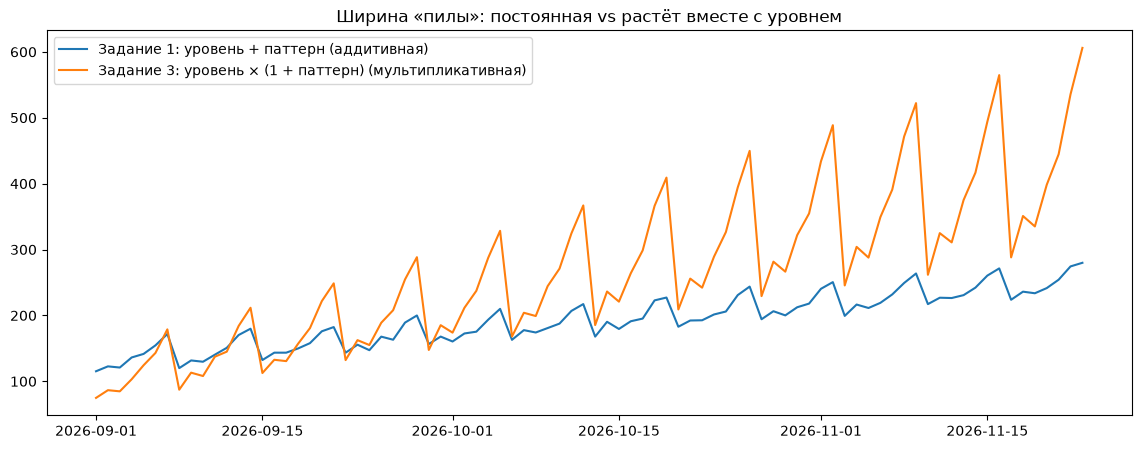

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["target"], label="Задание 1: уровень + паттерн (аддитивная)")
ax.plot(df_mul["timestamp"], df_mul["target"], label="Задание 3: уровень × (1 + паттерн) (мультипликативная)")
ax.legend(loc="upper left")
ax.set_title("Ширина «пилы»: постоянная vs растёт вместе с уровнем");

In [18]:
# Задание 3, шаг 2. 2 ряда × 2 типа сезонности = 4 модели; различаются ТОЛЬКО параметром seasonal
series_ts = {
    "add_series": ts,      # Задание 1: уровень + паттерн — «пила» постоянной ширины
    "mul_series": ts_mul,  # Задание 3: уровень × (1 + паттерн) — «пила» растёт с уровнем
}

seasonal_models = {}  # (ряд, тип сезонности) → обученная модель — понадобятся на шаге 4 для коэффициентов
smape_rows = []

for series_name, series in series_ts.items():
    train_s, test_s = series.train_test_split(test_size=HORIZON)

    for seasonal_type in ["add", "mul"]:
        model = HoltWintersModel(trend="add", seasonal=seasonal_type, seasonal_periods=7)
        model.fit(train_s)
        forecast_s = model.forecast(train_s.make_future(future_steps=HORIZON))

        seasonal_models[(series_name, seasonal_type)] = model
        smape_rows.append({
            "series": series_name,
            "seasonal": seasonal_type,
            "smape": SMAPE()(y_true=test_s, y_pred=forecast_s)["synthetic"],
        })

# Таблица 2 × 2: строки — ряд, колонки — тип сезонности модели
smape_2x2 = pd.DataFrame(smape_rows).pivot(index="series", columns="seasonal", values="smape").round(2)
smape_2x2

# Как читать таблицу:
# - диагональ add_series × add и mul_series × mul: модель правильного типа для своего ряда;
# - вне диагонали: модель неправильного типа.

seasonal,add,mul
series,,
add_series,1.01,1.52
mul_series,2.40,0.64


**Какой тип выигрывает?**
На каждом ряде выигрывает «свой» тип: лучшие значения стоят на диагонали. Модель, у которой тип сезонности совпадает с устройством ряда, ошибается меньше.

Ошибки несимметричны:
- mul-модель на аддитивном ряде: 1.52 против 1.01, хуже примерно в 1.5 раза;
- add-модель на мультипликативном ряде: 2.40 против 0.64, хуже почти в 4 раза.

Почему так, видно по тому, насколько сильно растёт уровень в каждом ряде:
- Аддитивный ряд: уровень растёт со 100 до ~225, примерно в 2 раза. mul-модель думает, что «пила» должна расширяться пропорционально уровню, и расширяет её. Это ошибка, но умеренная: за 12 недель уровень вырос не так уж сильно.
- Мультипликативный ряд: уровень растёт со 100 до ~430, больше чем в 4 раза, и «пила» расширяется так же. add-модель считает ширину «пилы» постоянной, а в реальности та уже в 4 раза шире, чем в начале. Модели приходится постоянно догонять, и на тесте она промахивается сильнее.

Отсюда практический вывод: **чем сильнее меняется уровень ряда, тем дороже ошибка в выборе типа сезонности**. Если ряд почти не растёт, add и mul дают почти одинаковый результат.

Нюанс. Абсолютные числа маленькие (0.6–2.4%), потому что синтетика чистая: идеальный узор и слабый шум. На реальных юнитах разница между add и mul будет меньше, и её легко спутать с шумом.


In [20]:
# Задание 3, шаг 4. Подобранные коэффициенты для всех 4 моделей
params_rows = []
for (series_name, seasonal_type), model in seasonal_models.items():
    p = model.get_model()["synthetic"].params
    params_rows.append({
        "series": series_name,
        "seasonal": seasonal_type,
        "correct": (series_name == "add_series") == (seasonal_type == "add"),  # тип модели совпадает с устройством ряда?
        "alpha (level)": p["smoothing_level"],
        "beta (trend)": p["smoothing_trend"],
        "gamma (seasonal)": p["smoothing_seasonal"],
    })
pd.DataFrame(params_rows).round(3)

,series,seasonal,correct,alpha (level),beta (trend),gamma (seasonal)
0,add_series,add,True,0.0,0.0,0.000
1,add_series,mul,False,0.0,0.0,0.489
2,mul_series,add,False,0.0,0.0,1.000
3,mul_series,mul,True,0.0,0.0,0.000


Главный коэффициент здесь `gamma (seasonal), скорость обновления сезонных поправок
- $\large \gamma ≈ 0$  — поправки подобраны один раз и больше не меняются. Так и должно быть, если модель правильно описывает узор: в синтетике он одинаковый каждую неделю, и обновлять нечего;
- $\large \gamma > 0$ — модель постоянно переписывает поправки. Значит, её поправки «не держатся»: каждую неделю реальность расходится с ними, и их приходится догонять.


Логика неправильной модели такая:
- add-модель на мультипликативном ряде считает, что «пила» постоянной ширины, а «пила» всё время расширяется. Модели остаётся одно: каждую неделю переписывать поправки под текущую ширину. Тогда γ должен быть большим;
- mul-модель на аддитивном ряде — обратная ситуация. Она расширяет «пилу» вместе с уровнем, а реальная «пила» стоит на месте. Ей тоже приходится подправлять поправки, но меньше, потому что уровень в аддитивном ряде вырос не так сильно (это видно и по SMAPE на шаге 3).

### Задание 4. Загрузи данные по 2 юнитам размера `10+`

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier) — так же, как для предыдущих моделей, с 2026-04-01.
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Посмотри на `ts.describe()`.
4. Построй `ts.plot()` и ответь глазами на три вопроса — от них зависит, какую клетку таксономии (раздел 1.3) брать в Задании 5:
   - **Есть ли тренд?** Линия уровня прямая и идёт вверх/вниз → аддитивный (`trend="add"`); загибается вверх → мультипликативный (`"mul"`); рост замедляется → с затуханием (`damped_trend=True`); направления нет → без тренда (`trend=None`).
   - **Есть ли сезонность и с каким периодом?** Повторяющаяся «пила» с шагом в неделю → `seasonal_periods=7`.
   - **Add или mul?** «Пила» одной ширины по всему ряду → `seasonal="add"`; расширяется по мере роста ряда → `seasonal="mul"`.
5. Раздели на train/test (последние `HORIZON` = 14 дней).

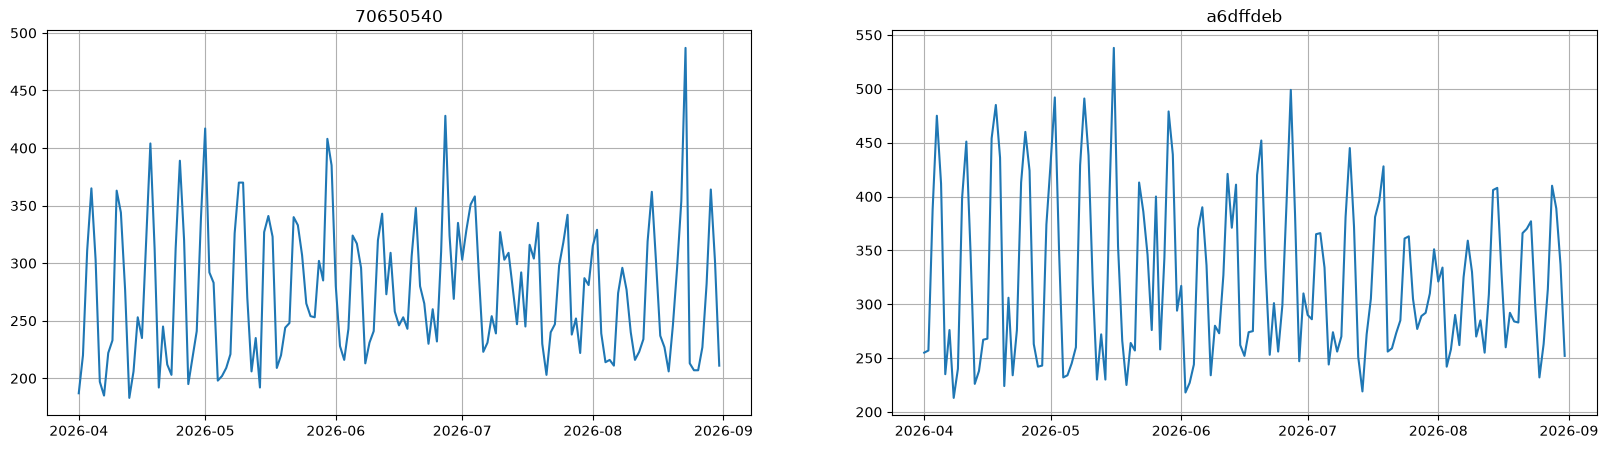

In [19]:
units_df = (pd
.read_csv(filepath_or_buffer=f"{DATA_DIR}/units.csv")
.rename(columns={
    "MaskedUnitId": "segment",
    "UnitSize": "unit_size",
    "PickReason": "pick_reason",
    "TotalOrders":"total_orders"
})
[["segment", "unit_size", "pick_reason", "total_orders"]]

)

orders_df = (
    pd.read_csv(f"{DATA_DIR}/facts-by-date.csv")
    .rename(columns={
        "CalendarDate": "timestamp",
        "MaskedUnitId": "segment",
        "Fact": "target",
    })
    [["timestamp", "segment", "target"]]
)

# Грязно выравниваем дату начала ряда, чтобы данные были по всем юнитам
orders_df = orders_df[orders_df['timestamp'] >= "2026-04-01"]
# Отбираем юниты
orders_sample_df = orders_df.merge(units_df[units_df["unit_size"] == "10+"]["segment"], how="inner", left_on="segment", right_on="segment", copy=True)

orders_sample_ts = TSDataset(orders_sample_df, freq="D")
orders_sample_ts.plot()

1. trend=None — гипотеза:
    - 70650540: ряд колеблется примерно в одном коридоре 200–350 весь период, направления нет.
    - a6dffdeb: здесь чуть сложнее. Нижняя граница стоит на месте (~220–260), а пики постепенно опускаются: в апреле–мае 480–530, в августе ~400. Средний уровень немного снижается, но это скорее следствие сжатия «пилы», чем выраженный тренд.
    - В Задании 5 стоит прогнать и trend=None, и trend="add": на 14 днях заметный тренд всё равно не успеет проявиться.

2. seasonal_periods=7. Недельная «пила» видна очень чётко, особенно у a6dffdeb.
3. «пила» затухает, особенно у a6dffdeb. Но это не признак мультипликативной сезонности. Мультипликативность значит, что ширина «пилы» пропорциональна уровню: уровень растёт, и «пила» шире, уровень падает, и уже. Здесь уровень почти не меняется, а «пила» всё равно сужается. Значит, со временем меняется сам недельный узор: разница между пиковыми и слабыми днями становится меньше. Тип сезонности тут ни при чём. За такую ситуацию отвечает не seasonal="add"/"mul", а $\large \gamma$, то есть скорость обновления сезонных поправок. Если узор меняется, модель должна понемногу его подстраивать. Поэтому в Задании 5 у реальных юнитов стоит ожидать $\large \gamma > 0$, в отличие от синтетики, где он был равен 0. По выбору add/mul: раз уровень почти постоянный, по выводу из Задания 3 разница между add и mul будет маленькой. Логичный выбор — seasonal="add" как более простой вариант, а "mul" прогнать для сравнения.

In [24]:
HORIZON = 14
train_units_ts, test_units_ts = orders_sample_ts.train_test_split(test_size=HORIZON)

### Задание 5. Подбираем конфигурацию на двух юнитах

1. Обучи сразу на обоих сегментах несколько конфигураций, от простого к сложному (коэффициенты — по умолчанию, подбираются в `fit()`):
   - `SimpleExpSmoothingModel()` и `HoltModel()` — как точка отсчёта без сезонности;
   - `HoltWintersModel(trend=None, seasonal="add", seasonal_periods=7)` — сезонность без тренда;
   - `HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7)`;
   - `HoltWintersModel(trend="add", seasonal="mul", seasonal_periods=7)`;
   - `HoltWintersModel(trend="add", damped_trend=True, seasonal="add", seasonal_periods=7)` — затухающий тренд: обычный аддитивный тренд — бесконечная прямая, на длинном горизонте прогноз может уйти в небо или в ноль, а затухание гасит наклон с каждым шагом. На 14 днях разница может быть небольшой.
2. Посчитай `SMAPE` — per-segment и `mode="macro"`, собери в одну таблицу (строки — конфигурации, колонки — юниты + macro).
3. Для лучшей конфигурации посмотри подобранные $\alpha$ / $\beta$ / $\gamma$ по каждому юниту (`get_model()[segment].params["smoothing_level"]` / `["smoothing_trend"]` / `["smoothing_seasonal"]`) и интерпретируй их (смысл коэффициентов — в разделе 1.2):
   - $\alpha$ близко к 1 — уровень сильно скачет, модель гонится за последними точками; близко к 0 — уровень стабильный, модель усредняет по длинной истории;
   - $\beta \approx 0$ — наклон почти не меняется (или тренда по сути нет);
   - $\gamma \approx 0$ — недельный узор фактически не обновляется, модель считает его постоянным; ближе к 1 — узор заметно меняется от недели к неделе.

   Насколько модель доверяет последним точкам? Обновляется ли недельный узор? Одинаково ли это у двух юнитов?
4. Попробуй ту же лучшую конфигурацию с **фиксированными** коэффициентами, как в пособии (например, `0.1 / 0.1 / 0.1`), — лучше или хуже, чем автоподбор?
5. Визуализируй лучшую конфигурацию через `plot_forecast` и разложи её прогноз на компоненты (`return_components=True`).

In [26]:
# Шаг 1. Конфигурации от простого к сложному. Коэффициенты α/β/γ не задаём — подбираются в fit()
configs = {
    # Точка отсчёта без сезонности
    "ses":             SimpleExpSmoothingModel(),  # только уровень
    "holt":            HoltModel(),                # уровень + тренд
    # Хольт-Винтерс
    "hw_none_add":     HoltWintersModel(trend=None, seasonal="add", seasonal_periods=7),   # сезонность без тренда
    "hw_add_add":      HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7),
    "hw_add_mul":      HoltWintersModel(trend="add", seasonal="mul", seasonal_periods=7),
    "hw_damped_add":   HoltWintersModel(trend="add", damped_trend=True, seasonal="add", seasonal_periods=7),
}

forecasts_units = {}  # имя конфигурации → прогноз на 14 дней теста (TSDataset с обоими юнитами)
for name, model in configs.items():
    model.fit(train_units_ts)
    forecasts_units[name] = model.forecast(train_units_ts.make_future(future_steps=HORIZON))

In [32]:
# Шаг 2. SMAPE по каждому юниту + macro — одна строка на конфигурацию
smape_rows = []
for name, forecast_ts in forecasts_units.items():
    # per-segment → словарь {segment: smape}, например {"70650540": 11.2, "a6dffdeb": 6.1}
    smape_per_segment = SMAPE(mode="per-segment")(y_true=test_units_ts, y_pred=forecast_ts)
    smape_rows.append({
        "config": name,
        **{f"smape_{segment}": value for segment, value in smape_per_segment.items()},
        # macro → одно число: простое среднее по двум юнитам — главная цифра для сравнения конфигураций
        "smape_macro": SMAPE(mode="macro")(y_true=test_units_ts, y_pred=forecast_ts),
    })

smape_hw_df = pd.DataFrame(smape_rows).set_index("config")
smape_hw_df["rank"] = smape_hw_df["smape_macro"].rank().astype(int)  # 1 — лучшая конфигурация по macro
smape_hw_df.round(2)

,smape_70650540,smape_a6dffdeb,smape_macro,rank
config,,,,
ses,22.49,15.22,18.86,6
holt,22.65,14.85,18.75,5
hw_none_add,9.21,6.33,7.77,1
hw_add_add,9.33,6.50,7.92,2
hw_add_mul,8.76,9.14,8.95,4
hw_damped_add,11.51,6.30,8.91,3


**Что видно:**
- Сезонность решает почти всё. ses / holt дают около 18.8, а любая модель Хольта-Винтерса — 7.8–9. Ошибка падает больше чем в 2 раза. Та же картина была в тетради про SARIMAX: без недельного узора эти ряды не прогнозируются.
- Тренд не помогает. holt ≈ ses (18.75 против 18.86), hw_add_add чуть хуже hw_none_add (7.92 против 7.77). Это подтверждает наблюдение по графикам о том, что **направления у рядов нет**. Лишний тренд не ломает модель, просто добавляет параметр, который здесь не нужен.
- Add или mul: результат смешанный. На 70650540 mul немного лучше (8.76 против 9.33), на a6dffdeb заметно хуже (9.14 против 6.50). В macro add выигрывает. Устойчивого преимущества у mul нет, что согласуется с выводом из Задания 3: при почти постоянном уровне тип сезонности большой разницы не даёт. Почему mul так проигрывает на a6dffdeb, отсюда сказать уверенно нельзя. Можно посмотреть его коэффициенты на шаге 3.
- Затухающий тренд ведёт себя странно. На a6dffdeb он в пределах шума от остальных (6.30), а на 70650540 заметно хуже (11.51 против 9.33). Теоретически затухающий тренд — что-то среднее между «без тренда» и «аддитивным», и ошибка должна лежать между ними. Скорее всего, у этой модели на одном юните оптимизатор подобрал совсем другие коэффициенты: у неё на один параметр больше (φ). Это тоже проверим на шаге 3.
- Лучшая конфигурация — hw_none_add: сезонность без тренда, самая простая из моделей с сезонностью.

In [33]:
# Шаг 3. Подобранные α/β/γ лучшей конфигурации — по каждому юниту
best_name = "hw_none_add"

coef_rows = []
for segment, fit_res in configs[best_name].get_model().items():
    p = fit_res.params
    coef_rows.append({
        "segment": segment,
        "alpha (level)": p["smoothing_level"],
        "beta (trend)": p["smoothing_trend"],       # у trend=None будет nan — тренда в модели нет
        "gamma (seasonal)": p["smoothing_seasonal"],
    })
pd.DataFrame(coef_rows).set_index("segment").round(3)

,alpha (level),beta (trend),gamma (seasonal)
segment,,,
70650540,0.072,NaN,0.000
a6dffdeb,0.004,NaN,0.177


Чтобы числа читались интуитивно, переведем их в период полураспада: через сколько шагов вес наблюдения в оценке уменьшается вдвое. Он считается как $\ln 0.5 / \ln(1 - \text{коэффициент})$.

**70650540**: уровень понемногу подстраивается, узор постоянный
- α = 0.072, полураспад ≈ 9 дней. Уровень обновляется медленно, но всё-таки обновляется: на него в основном влияют последние 1–3 недели.
-  γ = 0: недельный узор не меняется, модель использует одни и те же поправки на весь период.

**a6dffdeb**: уровень почти заморожен, узор меняется
- α = 0.004, полураспад ≈ 170 дней. Это больше всего train (139 дней), то есть уровень фактически постоянный: модель считает, что базовая величина у этого юнита не меняется.
- γ = 0.177, полураспад ≈ 3.5 недели. Недельный узор обновляется: каждая новая неделя сдвигает поправку соответствующего дня примерно на 18% в свою сторону. Это подтверждает твоё наблюдение по графикам, что «пила» у a6dffdeb со временем сужается. Модель увидела это сама и подстраивает поправки.

**Ответы на вопросы шага 3**:
- Насколько модель доверяет последним точкам? Слабо у обоих юнитов: α маленькое, уровень сглаживается по длинной истории. Это нормально для рядов без тренда.
- Обновляется ли недельный узор? У 70650540 нет, у a6dffdeb да.
- Одинаково ли у двух юнитов? Нет, ровно наоборот: у одного юнита гуляет уровень, а узор стоит, у другого стоит уровень, а гуляет узор. Хотя оба юнита одного размера (10+), устроены они по-разному. Для Бонуса с 10 юнитами это сигнал: одна конфигурация подойдёт всем, но коэффициенты у каждого будут свои, и автоподбор здесь как раз уместен.

In [34]:
# Шаг 4. Лучшая конфигурация, но коэффициенты фиксируем руками, как в пособии
model_fixed = HoltWintersModel(
    trend=None, seasonal="add", seasonal_periods=7,
    smoothing_level=0.1,     # α — одинаковый для обоих юнитов
    smoothing_seasonal=0.1,  # γ
)
model_fixed.fit(train_units_ts)
forecast_fixed = model_fixed.forecast(train_units_ts.make_future(future_steps=HORIZON))

compare_fixed = pd.DataFrame({
    "auto (подбор в fit)": SMAPE(mode="per-segment")(y_true=test_units_ts, y_pred=forecasts_units[best_name]),
    "fixed 0.1 / 0.1":     SMAPE(mode="per-segment")(y_true=test_units_ts, y_pred=forecast_fixed),
}).T
compare_fixed["macro"] = compare_fixed.mean(axis=1)
compare_fixed.round(2)

,70650540,a6dffdeb,macro
auto (подбор в fit),9.21,6.33,7.77
fixed 0.1 / 0.1,9.43,7.20,8.32


Почему у a6dffdeb ухудшение сильнее?

Всё дело в том, насколько 0.1 / 0.1 далеко от подобранных значений:
- 70650540: подобрано $\alpha = 0.072$, $\gamma = 0$, то есть фиксированное $\alpha = 0.1$ почти совпадает. $\gamma = 0.1$ вместо 0 заставляет модель немного подстраивать узор, которому подстройка не нужна, и он подхватывает шум. Ухудшение маленькое: +0.22.
- a6dffdeb: подобрано $\alpha = 0.004$, $\gamma = 0.177$. Фиксированные значения промахиваются по обоим коэффициентам, причём в противоположные стороны:
$\alpha = 0.1$ в 25 раз больше подобранного. Модель начинает гоняться за последними точками, хотя уровень этого юнита стабилен;
$\gamma = 0.1$ почти вдвое меньше подобранного. Модель медленнее подстраивает сужающуюся «пилу».

Отсюда ухудшение в 4 раза больше: +0.87.

Вывод
Автоподбор лучше на обоих юнитах, и тем заметнее, чем сильнее «настоящие» коэффициенты юнита отличаются от фиксированных.
Универсальных коэффициентов нет. 0.1 / 0.1 из пособия подобраны для их примера, а у реальных юнитов свои паттерны. Фиксировать коэффициенты имеет смысл, только если ты знаешь о ряде что-то, чего не видит оптимизатор.
Оговорка: автоподбор оптимизирует ошибку на train (прогноз на шаг вперёд), а не на тесте. Поэтому выигрыш на тесте не гарантирован. Здесь он есть, но на коротком или нестабильном ряде фиксированные коэффициенты иногда оказываются устойчивее.

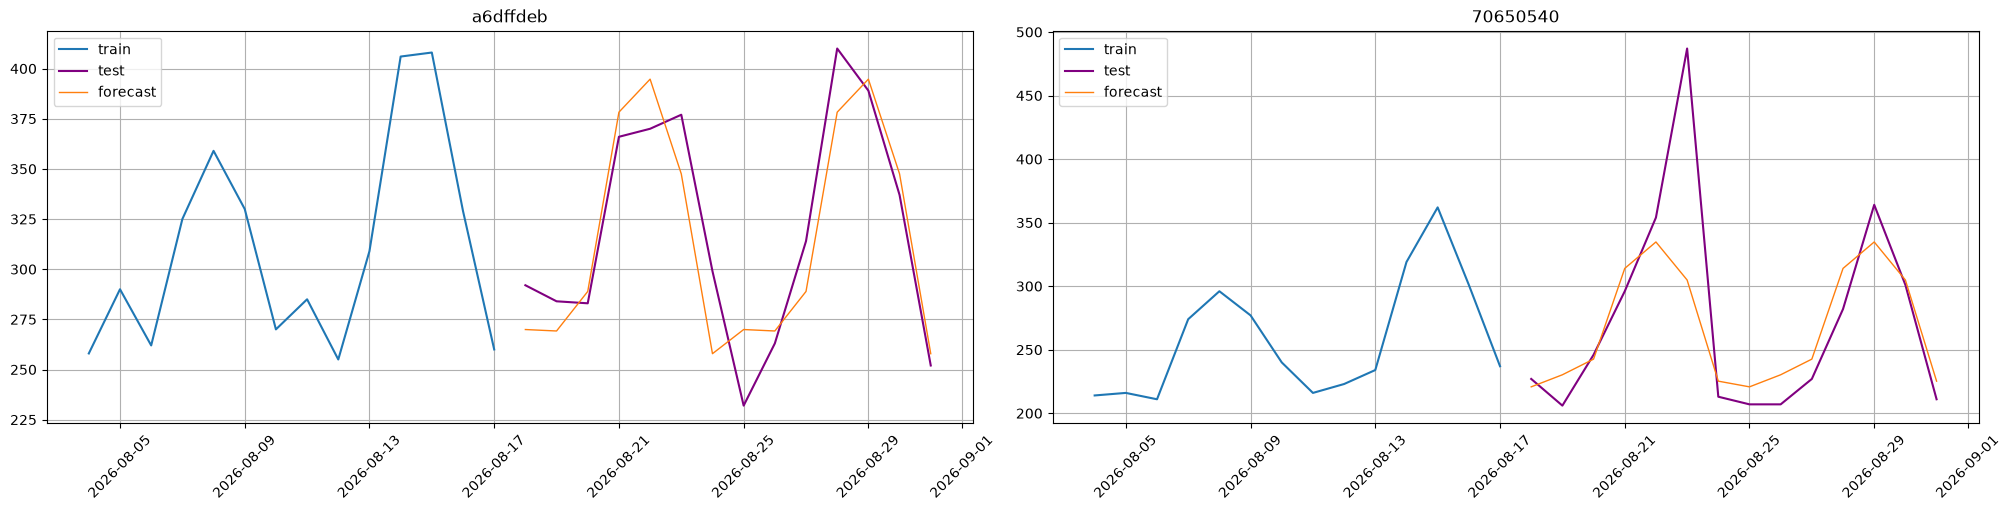

In [36]:
# Задание 5, шаг 5а. Прогноз лучшей конфигурации на фоне последних 2 недель train и теста
plot_forecast(
    forecast_ts=forecasts_units[best_name],
    test_ts=test_units_ts,
    train_ts=train_units_ts,
    n_train_samples=2 * 7,
)

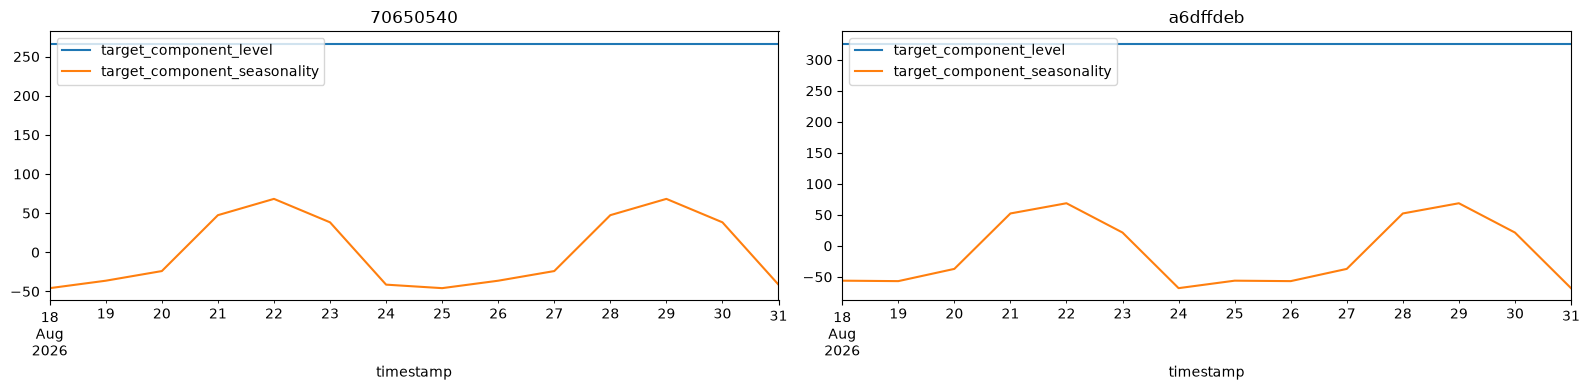

In [37]:
# Задание 5, шаг 5б. Из чего собран прогноз: компоненты по каждому юниту
forecast_best_comp = configs[best_name].forecast(
    train_units_ts.make_future(future_steps=HORIZON),
    return_components=True,
)
components_best = forecast_best_comp.get_target_components()  # колонки: (segment, компонента)

fig, axes = plt.subplots(1, len(train_units_ts.segments), figsize=(16, 4))
for ax, segment in zip(axes, train_units_ts.segments):
    components_best[segment].plot(ax=ax, title=segment)
    ax.legend(loc="upper left")
plt.tight_layout()

**На что смотреть:**
- у hw_none_add нет тренда, поэтому компонент будет два: level (горизонтальная линия, $\ell_t$ последнего дня train) и seasonality (недельная «пила» поправок);

### Бонус. Общая картина по всем 10 юнитам + логирование

1. Прогони 2–3 лучшие конфигурации из Задания 5 сразу на всех 10 юнитах (используй `orders_df` из Задания 4 без фильтра по `unit_size`).
2. Посчитай весь набор метрик — `SMAPE`, `WAPE`, `MAPE`, `MAE`, `Bias` (через `src/prod_metrics.py`), per-segment и агрегированно.
3. Собери всё в одну таблицу `result` (`segment`/`unit_size`/`pick_reason`/`total_orders` + подобранные $\alpha$ / $\beta$ / $\gamma$ + все метрики) — подобранные коэффициенты по юнитам покажут, насколько разные у них паттерны.
4. Залогируй каждую конфигурацию отдельным запуском через `log_to_mlflow(...)` — по аналогии с бонусом SARIMAX:
   - имя запуска: `HoltWinters_<вариант>_ch06_all_10_day`, например `HoltWinters_add_add_ch06_all_10_day`;
   - теги: `{"chapter": "ch06", "units_scope": "all_10", "granularity": "day", "model_family": "ets", "impl": "statsmodels"}` + свой тег варианта (например, `"trend": "add"`, `"seasonal": "mul"`, `"damped": "true"`);
   - тогда в MLflow запуски Хольта-Винтерса встанут рядом с `NaiveModel` / `MovingAverageModel` / `SeasonalMovingAverageModel` / `SARIMAX_*` в одной таблице.

In [38]:
# Шаг 1. Все 10 юнитов: тот же orders_df из Задания 4 (с 2026-04-01), но без фильтра по unit_size.
# Период и горизонт — как у всех прошлых запусков в MLflow, поэтому метрики сравнимы напрямую.
orders_all_ts = TSDataset(orders_df, freq="D")
train_all_ts, test_all_ts = orders_all_ts.train_test_split(test_size=HORIZON)

print(f"train: {train_all_ts.timestamps.min().date()} … {train_all_ts.timestamps.max().date()}")
print(f"test:  {test_all_ts.timestamps.min().date()} … {test_all_ts.timestamps.max().date()}")
print(f"segments ({len(train_all_ts.segments)}): {train_all_ts.segments}")


# Конфигурации для логирования. Модели создаются функцией ЗАНОВО — объекты в configs уже обучены на 2 юнитах.
# Для каждой — всё, что уйдёт в MLflow:
#   run_label — имя запуска (к нему добавится суффикс _ch06_all_10_day);
#   tags      — trend / seasonal / damped: по ним удобно фильтровать запуски в UI;
#   params    — параметры модели (params в MLflow).
def make_hw_models():
    return {
        "ses": {
            "run_label": "ExpSmoothing_ses",
            "tags": {"trend": "none", "seasonal": "none", "damped": "false"},
            "params": {},
            "model": SimpleExpSmoothingModel(),
        },
        "hw_none_add": {
            "run_label": "HoltWinters_none_add",
            "tags": {"trend": "none", "seasonal": "add", "damped": "false"},
            "params": {"trend": None, "seasonal": "add", "seasonal_periods": 7},
            "model": HoltWintersModel(trend=None, seasonal="add", seasonal_periods=7),
        },
        "hw_add_add": {
            "run_label": "HoltWinters_add_add",
            "tags": {"trend": "add", "seasonal": "add", "damped": "false"},
            "params": {"trend": "add", "seasonal": "add", "seasonal_periods": 7},
            "model": HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7),
        },
        "hw_add_mul": {
            "run_label": "HoltWinters_add_mul",
            "tags": {"trend": "add", "seasonal": "mul", "damped": "false"},
            "params": {"trend": "add", "seasonal": "mul", "seasonal_periods": 7},
            "model": HoltWintersModel(trend="add", seasonal="mul", seasonal_periods=7),
        },
        "hw_damped_add": {
            "run_label": "HoltWinters_damped_add",
            "tags": {"trend": "add", "seasonal": "add", "damped": "true"},
            "params": {"trend": "add", "damped_trend": True, "seasonal": "add", "seasonal_periods": 7},
            "model": HoltWintersModel(trend="add", damped_trend=True, seasonal="add", seasonal_periods=7),
        },
    }

train: 2026-04-01 … 2026-08-17
test:  2026-08-18 … 2026-08-31
segments (10): ['155082de', '3bfb39ef', '70650540', '733e17e8', '8a399130', '9bb64107', 'a5cd0472', 'a6dffdeb', 'aa88e1ec', 'd3319417']


In [39]:
# Шаг 2. Обучаем каждую конфигурацию на всех 10 юнитах и считаем полный набор метрик
hw_models = make_hw_models()
hw_runs = {}  # имя конфигурации → всё для логирования в MLflow: метрики, таблица по юнитам

for name, spec in hw_models.items():
    model = spec["model"]

    started = time.perf_counter()
    model.fit(train_all_ts)
    forecast_ts = model.forecast(train_all_ts.make_future(future_steps=HORIZON))
    fit_sec = time.perf_counter() - started

    # Метрики по каждому юниту — словари {segment: значение}. Тот же набор, что у всех прошлых запусков.
    # Внимание: WAPE() из ETNA — доля (0.08), а pooled()/bias() — проценты (8.0). Так было и в прошлых запусках.
    per_segment = {
        "smape": SMAPE()(y_true=test_all_ts, y_pred=forecast_ts),
        "wape": WAPE()(y_true=test_all_ts, y_pred=forecast_ts),
        "mape": MAPE()(y_true=test_all_ts, y_pred=forecast_ts),
        "mae": MAE()(y_true=test_all_ts, y_pred=forecast_ts),
        "bias": bias(y_true=test_all_ts, y_pred=forecast_ts),
    }
    # Агрегаты по всем 10 юнитам — одно число на метрику. Имена — как в прошлых запусках, чтобы графики в MLflow совпали.
    agg = {
        "smape_macro": SMAPE(mode="macro")(y_true=test_all_ts, y_pred=forecast_ts),  # среднее по юнитам
        "mape_macro": MAPE(mode="macro")(y_true=test_all_ts, y_pred=forecast_ts),
        "mae_macro": MAE(mode="macro")(y_true=test_all_ts, y_pred=forecast_ts),
        "wape_pooled": pooled(test_all_ts, forecast_ts, signed=False),  # взвешено по объёму заказов
        "bias_pooled": pooled(test_all_ts, forecast_ts, signed=True),
        "fit_sec": fit_sec,
    }

    # Таблица по юнитам: описание юнита + подобранные α/β/γ + все метрики. В MLflow — артефакт metrics_by_segment.json.
    # У моделей без тренда/сезонности соответствующего коэффициента нет — там будет nan.
    result = units_df.copy()
    fitted = model.get_model()  # {segment: HoltWintersResultsWrapper}
    for coef_name, param_key in [("alpha", "smoothing_level"), ("beta", "smoothing_trend"), ("gamma", "smoothing_seasonal")]:
        result[coef_name] = result["segment"].map(lambda s: fitted[s].params.get(param_key, np.nan))
    for metric_name, values in per_segment.items():
        result[metric_name] = result["segment"].map(values)

    hw_runs[name] = {"spec": spec, "per_segment": per_segment, "agg": agg, "result": result}
    print(f"{name:<15} smape_macro={agg['smape_macro']:6.2f}  wape_pooled={agg['wape_pooled']:6.2f}  fit_sec={fit_sec:5.2f}")

ses             smape_macro= 16.85  wape_pooled= 16.65  fit_sec= 0.08
hw_none_add     smape_macro= 11.36  wape_pooled=  9.77  fit_sec= 0.12
hw_add_add      smape_macro= 11.31  wape_pooled= 10.00  fit_sec= 0.32
hw_add_mul      smape_macro= 11.40  wape_pooled= 10.43  fit_sec= 0.29
hw_damped_add   smape_macro= 11.68  wape_pooled= 10.14  fit_sec= 0.35


In [40]:
# Щаг 3а. Сводка: одна строка на конфигурацию, все агрегированные метрики
# Для ориентира — прошлые модели на тех же 10 юнитах и тех же 14 днях (из MLflow), smape_macro:
#   NaiveModel 13.92 · MovingAverageModel 15.95 · SeasonalMovingAverageModel 11.72
#   SARIMAX: default 39.10 · one_config_second 11.34 · one_config_first 11.88 · auto_pmdarima 12.24 · auto_statsforecast 12.62
hw_summary = pd.DataFrame([
    {"config": name, **run["spec"]["tags"], **run["agg"]}
    for name, run in hw_runs.items()
]).set_index("config")
hw_summary["rank"] = hw_summary["smape_macro"].rank().astype(int)  # 1 — лучшая по smape_macro
hw_summary.round(2)

,trend,seasonal,damped,smape_macro,mape_macro,mae_macro,wape_pooled,bias_pooled,fit_sec,rank
config,,,,,,,,,,
ses,none,none,false,16.85,20.59,25.76,16.65,1.60,0.08,5
hw_none_add,none,add,false,11.36,13.91,15.12,9.77,0.26,0.12,2
hw_add_add,add,add,false,11.31,13.80,15.46,10.00,-0.03,0.32,1
hw_add_mul,add,mul,false,11.40,13.74,16.13,10.43,-1.39,0.29,3
hw_damped_add,add,add,true,11.68,14.62,15.69,10.14,1.22,0.35,4


In [42]:
# Шаг 3б. SMAPE по каждому юниту × конфигурации. Строки — юниты от крупных к мелким.
smape_by_unit_hw = (
    units_df.set_index("segment")[["unit_size", "pick_reason", "total_orders"]]
    .join(pd.DataFrame({name: run["per_segment"]["smape"] for name, run in hw_runs.items()}))
    .sort_values("total_orders", ascending=False)
)
smape_by_unit_hw.round(2)

,unit_size,pick_reason,total_orders,ses,hw_none_add,hw_add_add,hw_add_mul,hw_damped_add
segment,,,,,,,,
a6dffdeb,10+,busier (p75),29099,15.22,6.33,6.50,9.14,6.30
70650540,10+,typical (p25),25437,22.49,9.21,9.33,8.76,11.51
aa88e1ec,7–10,busier (p75),19363,18.61,12.39,13.47,13.65,11.95
d3319417,7–10,typical (p25),17464,16.04,12.17,13.30,11.58,12.18
155082de,5–7,busier (p75),13509,11.12,7.04,6.84,8.82,7.03
733e17e8,5–7,typical (p25),12470,10.97,8.19,8.27,8.38,8.11
3bfb39ef,3–5,busier (p75),9530,14.74,10.17,10.19,10.28,10.27
9bb64107,3–5,typical (p25),7888,11.35,9.53,9.79,9.18,9.53
8a399130,<3,busier (p75),5646,22.46,18.49,15.12,13.90,17.56


In [43]:
# Шаг 3в. Подобранные α/γ лучшей конфигурации по каждому юниту — насколько по-разному устроены юниты
best_hw = hw_summary["smape_macro"].idxmin()
print(f"лучшая конфигурация: {best_hw}")
(
    hw_runs[best_hw]["result"]
    .set_index("segment")[["unit_size", "total_orders", "alpha", "beta", "gamma", "smape"]]
    .sort_values("total_orders", ascending=False)
    .round(3)
)

лучшая конфигурация: hw_add_add


,unit_size,total_orders,alpha,beta,gamma,smape
segment,,,,,,
a6dffdeb,10+,29099,0.000,0.0,0.153,6.498
70650540,10+,25437,0.072,0.0,0.000,9.335
aa88e1ec,7–10,19363,0.275,0.0,0.000,13.469
d3319417,7–10,17464,0.090,0.0,0.000,13.299
155082de,5–7,13509,0.261,0.0,0.134,6.840
733e17e8,5–7,12470,0.069,0.0,0.000,8.268
3bfb39ef,3–5,9530,0.000,0.0,0.000,10.191
9bb64107,3–5,7888,0.320,0.0,0.000,9.786
8a399130,<3,5646,0.000,0.0,0.000,15.119


In [44]:
# Шаг 4. Логируем каждую конфигурацию отдельным запуском. Как потом найти их в MLflow UI:
#
#   Имя запуска:  <run_label>_ch06_all_10_day, например HoltWinters_none_add_ch06_all_10_day
#                 — читается на графиках рядом с NaiveModel_ch02_all_10_day, SARIMAX_*_ch05_all_10_day и остальными.
#   Теги (фильтр в строке поиска UI, например:  tags.model_family = "ets"):
#     chapter      = ch06                              — как у прошлых запусков: ch02 … ch05;
#     units_scope  = all_10, granularity = day         — как у прошлых запусков;
#     model_family = ets                               — все варианты экспоненциального сглаживания одним фильтром;
#     approach     = baseline / one_config             — как у SARIMAX: ses без сезонности — baseline,
#                                                        Хольт-Винтерс — одна конфигурация на все юниты (α/β/γ подбираются по юниту);
#     impl         = statsmodels                       — чья реализация внутри;
#     trend / seasonal / damped                        — клетка таксономии: none/add/mul, true/false.
#   Параметры (params): trend / seasonal / seasonal_periods / damped_trend + horizon.
#   Артефакт metrics_by_segment.json: таблица по юнитам, в т.ч. подобранные α/β/γ для каждого.
for name, run in hw_runs.items():
    spec = run["spec"]
    log_to_mlflow(
        model_name=spec["run_label"],
        model_params={**{k: str(v) for k, v in spec["params"].items()}, "horizon": HORIZON},
        metrics=run["agg"],
        metrics_per_segment=run["per_segment"],
        segment_table=run["result"],
        tags={
            "chapter": "ch06",
            "units_scope": "all_10",
            "granularity": "day",
            "model_family": "ets",
            "approach": "baseline" if name == "ses" else "one_config",
            "impl": "statsmodels",
            **spec["tags"],  # trend / seasonal / damped
        },
        run_name_suffix="ch06_all_10_day",
    )

In [45]:
import mlflow  # трекинг уже настроен импортом src.custom_logger

runs_df = mlflow.search_runs(
    experiment_names=["study-etna"],
    filter_string="tags.units_scope = 'all_10'",
)
runs_df["run"] = runs_df["tags.mlflow.runName"].str.removesuffix("_all_10_day")

# Какие модели сравниваем — можно добавить любые из списка запусков
compare_runs = ["HoltWinters_add_add_ch06", "SARIMAX_one_config_second_ch05"]

# Строки — юниты, колонки — модели, значения — SMAPE на 14 днях теста
smape_cols = [c for c in runs_df.columns if c.startswith("metrics.smape/")]
smape_unit_x_model = (
    runs_df.set_index("run").loc[compare_runs, smape_cols]
    .T.rename(index=lambda c: c.removeprefix("metrics.smape/"))
)

# Описание юнита + кто лучше + на сколько
smape_unit_x_model = units_df.set_index("segment")[["unit_size", "total_orders"]].join(smape_unit_x_model)
smape_unit_x_model["winner"] = smape_unit_x_model[compare_runs].idxmin(axis=1)
smape_unit_x_model["diff"] = smape_unit_x_model[compare_runs[0]] - smape_unit_x_model[compare_runs[1]]  # < 0 — первая модель лучше
smape_unit_x_model = smape_unit_x_model.sort_values("total_orders", ascending=False)

# Подсветка: зелёным — лучшая модель в строке
smape_unit_x_model.style.format(precision=2).highlight_min(subset=compare_runs, axis=1, color="lightgreen")

,unit_size,total_orders,HoltWinters_add_add_ch06,SARIMAX_one_config_second_ch05,winner,diff
segment,,,,,,
a6dffdeb,10+,29099,6.50,5.63,SARIMAX_one_config_second_ch05,0.87
70650540,10+,25437,9.33,9.22,SARIMAX_one_config_second_ch05,0.11
aa88e1ec,7–10,19363,13.47,8.84,SARIMAX_one_config_second_ch05,4.63
d3319417,7–10,17464,13.30,10.49,SARIMAX_one_config_second_ch05,2.81
155082de,5–7,13509,6.84,10.71,HoltWinters_add_add_ch06,-3.87
733e17e8,5–7,12470,8.27,7.05,SARIMAX_one_config_second_ch05,1.22
3bfb39ef,3–5,9530,10.19,11.16,HoltWinters_add_add_ch06,-0.97
9bb64107,3–5,7888,9.79,8.32,SARIMAX_one_config_second_ch05,1.46
8a399130,<3,5646,15.12,18.92,HoltWinters_add_add_ch06,-3.80
